final mRNA: 71.42857142856636, expected: 71.42857142857142


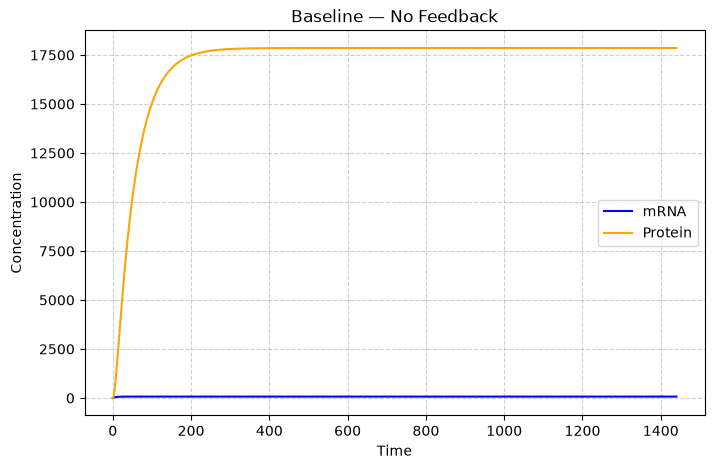

In [9]:
#Stage 1: Creating baseline where transcription and translation rates are constant and mRNA and protein are generating without any feedback to repress them

import matplotlib.pyplot as plt

ym = 0.14
yp = 0.02
beta = 5.0
alpha = 10.0
dt = 0.01
time_data = []
mrna_data = []
protein_data = []
dm_dt = 0
dp_dt = 0
for i in range(144000):
    time_data.append(i * dt)
    mrna_data.append(dm_dt)
    protein_data.append(dp_dt)
    #Keeping transcription rate = alpha
    dm_dt += (alpha - (ym * dm_dt)) * dt
    dp_dt += ((beta * dm_dt) - (yp * dp_dt)) * dt


print(f"final mRNA: {dm_dt}, expected: {alpha/ym}")


plt.figure(figsize=(8, 5))
        
# Plot both variables
plt.plot(time_data, mrna_data, color='blue', label='mRNA')
plt.plot(time_data, protein_data, color='orange', label='Protein')
        
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Baseline — No Feedback")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
        
plt.show()

#Output generated is corroborated by putting the same values in mRNA and protein equation by keeping dm/dt and dp/dt zero

peak protein: 588.3060144942627, final protein: 281.17961189124514, ratio: 2.0922783502589377


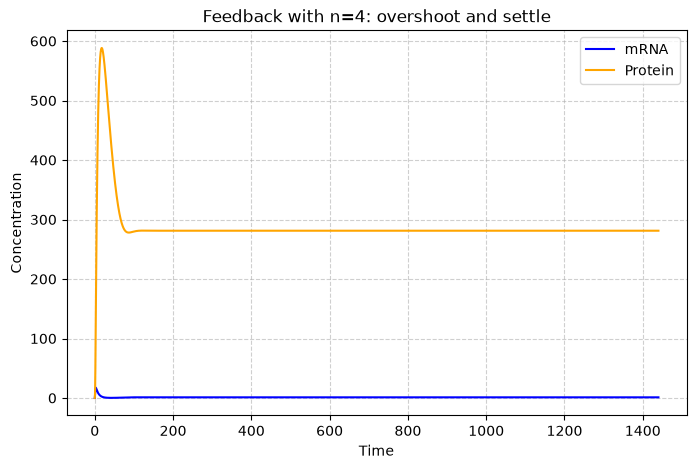

In [11]:
#Stage 2: Adding repressor function (hill function). Basically adding negative feedback

import matplotlib.pyplot as plt
class GeneNetwork:

    def __init__(self, alpha, kd, n, beta, ym, yp, dt, mrna_initial_conc, protein_initial_conc):
        self.alpha = alpha
        self.kd = kd
        self.n = n
        self.beta = beta
        self.ym = ym
        self.yp = yp
        self.dt = dt
        self.mrna_initial_conc = mrna_initial_conc
        self.protein_initial_conc = protein_initial_conc
        self.time_data = []
        self.mrna_data = []
        self.protein_data = []

    def simulate(self, steps):
        current_mrna_conc = self.mrna_initial_conc
        current_protein_conc = self.protein_initial_conc
        for i in range(steps):
            self.time_data.append(i * self.dt)
            self.mrna_data.append(current_mrna_conc)
            self.protein_data.append(current_protein_conc)
            
            transcription_rate = self.alpha/(1 + (current_protein_conc/self.kd) ** self.n)
            mrna_conc = transcription_rate - (self.ym * current_mrna_conc)
            protein_conc = (self.beta * current_mrna_conc) - (self.yp * current_protein_conc)

            current_mrna_conc += mrna_conc * self.dt
            current_protein_conc += protein_conc * self.dt
        return self.time_data, self.mrna_data, self.protein_data

    def plotter(self):
        plt.figure(figsize=(8, 5))
        
        # Plot both variables
        plt.plot(self.time_data, self.mrna_data, color='blue', label='mRNA')
        plt.plot(self.time_data, self.protein_data, color='orange', label='Protein')
        
        plt.xlabel("Time")
        plt.ylabel("Concentration")
        plt.title("Feedback with n=4: overshoot and settle")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        
        plt.show()


gene_A = GeneNetwork(10.0, 100.0, 4, 5.0, 0.14, 0.02, 0.01, 0.0, 0.0)
gene_A.simulate(144000)
print(f"peak protein: {max(gene_A.protein_data)}, final protein: {gene_A.protein_data[-1]}, ratio: {max(gene_A.protein_data)/gene_A.protein_data[-1]}")
gene_A.plotter()

160.08647413775574
160.08647413778112


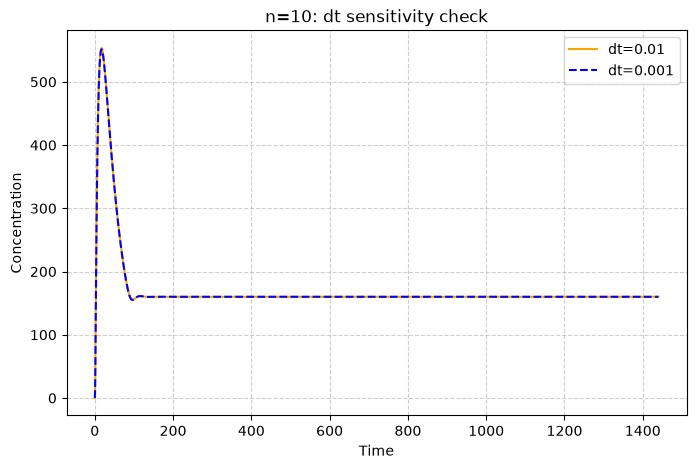

In [15]:
#Stage 3: A numerical artifact I almost missed

import matplotlib.pyplot as plt
class GeneNetwork:

    def __init__(self, alpha, kd, n, beta, ym, yp, dt, mrna_initial_conc, protein_initial_conc):
        self.alpha = alpha
        self.kd = kd
        self.n = n
        self.beta = beta
        self.ym = ym
        self.yp = yp
        self.dt = dt
        self.mrna_initial_conc = mrna_initial_conc
        self.protein_initial_conc = protein_initial_conc
        self.time_data = []
        self.mrna_data = []
        self.protein_data = []

    def simulate(self, steps):
        current_mrna_conc = self.mrna_initial_conc
        current_protein_conc = self.protein_initial_conc
        for i in range(steps):
            self.time_data.append(i * self.dt)
            self.mrna_data.append(current_mrna_conc)
            self.protein_data.append(current_protein_conc)
            
            transcription_rate = self.alpha/(1 + (current_protein_conc/self.kd) ** self.n)
            mrna_conc = transcription_rate - (self.ym * current_mrna_conc)
            protein_conc = (self.beta * current_mrna_conc) - (self.yp * current_protein_conc)

            current_mrna_conc += mrna_conc * self.dt
            current_protein_conc += protein_conc * self.dt
        return self.time_data, self.mrna_data, self.protein_data

    def plotter(self):
        plt.figure(figsize=(8, 5))
        
        # Plot both variables
        plt.plot(self.time_data, self.mrna_data, color='blue', label='mRNA')
        plt.plot(self.time_data, self.protein_data, color='orange', label='Protein')
        
        plt.xlabel("Time")
        plt.ylabel("Concentration")
        plt.title("Gene Expression with steep hill coefficient")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        
        plt.show()


gene_B = GeneNetwork(10.0, 100.0, 10, 5.0, 0.14, 0.02, .01, 0.0, 0.0)
gene_B.simulate(144000)
print(gene_B.protein_data[-1])

gene_C = GeneNetwork(10.0, 100.0, 10, 5.0, 0.14, 0.02, .001, 0.0, 0.0)
gene_C.simulate(1440000)
print(gene_C.protein_data[-1])

plt.figure(figsize=(8,5))
plt.plot(gene_B.time_data, gene_B.protein_data, label="dt=0.01", color="orange")
plt.plot(gene_C.time_data, gene_C.protein_data, label="dt=0.001", color="blue", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("n=10: dt sensitivity check")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

[(1, 1.0), (2, 1.3162784263695413), (4, 2.0922783502589377), (8, 3.1335519283389055), (10, 3.4579998705444166)]


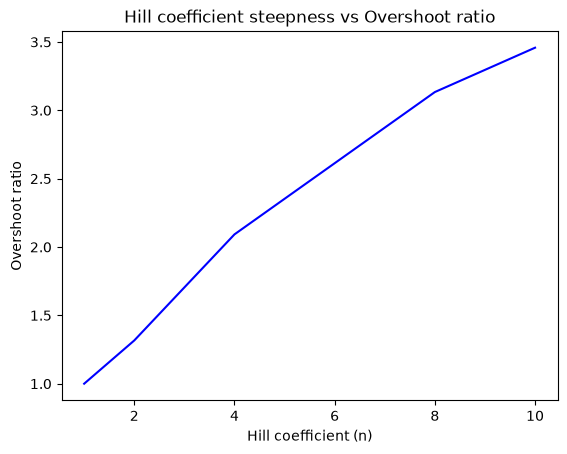

In [20]:
#Stage 4: How Overshoot Actually Scales with Feedback Steepness

import matplotlib.pyplot as plt
class GeneNetwork:

    def __init__(self, n, alpha=10.0, kd=100.0, beta=5.0, ym=0.14, yp=0.02, dt=0.01, mrna_initial_conc=0, protein_initial_conc=0):
        self.alpha = alpha
        self.kd = kd
        self.n = n
        self.beta = beta
        self.ym = ym
        self.yp = yp
        self.dt = dt
        self.mrna_initial_conc = mrna_initial_conc
        self.protein_initial_conc = protein_initial_conc
        self.time_data = []
        self.mrna_data = []
        self.protein_data = []

    def simulate(self, steps):
        current_mrna_conc = self.mrna_initial_conc
        current_protein_conc = self.protein_initial_conc
        for i in range(steps):
            self.time_data.append(i * self.dt)
            self.mrna_data.append(current_mrna_conc)
            self.protein_data.append(current_protein_conc)
            
            transcription_rate = self.alpha/(1 + (current_protein_conc/self.kd) ** self.n)
            dmrna = transcription_rate - (self.ym * current_mrna_conc)
            dprotein = (self.beta * current_mrna_conc) - (self.yp * current_protein_conc)

            current_mrna_conc += dmrna * self.dt
            current_protein_conc += dprotein * self.dt

        return self.time_data, self.mrna_data, self.protein_data

    def plotter(self):
        plt.figure(figsize=(8, 5))
        
        # Plot both variables
        plt.plot(self.time_data, self.mrna_data, color='blue', label='mRNA')
        plt.plot(self.time_data, self.protein_data, color='orange', label='Protein')
        
        plt.xlabel("Time")
        plt.ylabel("Concentration")
        plt.title("Gene Expression with steep hill coefficient")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        
        plt.show()
        
n_items = [1,2,4,8,10]
overshoot_pairs = []
for item in n_items:

    new_gene = GeneNetwork(n=item)
    new_gene.simulate(144000)
    overshoot_ratio = max(new_gene.protein_data) / (new_gene.protein_data)[-1]
    overshoot_pairs.append((item, overshoot_ratio))
print(overshoot_pairs, sep='\n')
x_values, y_values = zip(*overshoot_pairs)
plt.plot(x_values, y_values, color='blue')
plt.xlabel('Hill coefficient (n)')
plt.ylabel('Overshoot ratio')
plt.title('Hill coefficient steepness vs Overshoot ratio')
plt.show()